# Phase 7: Answering SQ2, SQ3 and SQ4

This notebook has three parts, one for each sub-question:

| Part | Question | Method | Figure |
|---|---|---|---|
| A | SQ2: baseline relation between distance and car ownership | regression with control variables | coefficient plot |
| B | SQ3: major vs. minor stations | regression per station type + interaction | two scatter plots |
| C | SQ4: role of disruptions | regression with interaction | 3D surface (as in the lecture) |

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

PROCESSED = Path('data/cleaned_data')
master = pd.read_pickle(PROCESSED / 'master.pkl')

## Preparation

- CBS codes urbanisation from 1 (very urban) to 5 (not urban). That is confusing to read, so we turn it around: `stedelijk` goes from 1 (not urban) to 5 (very urban).
- Density in thousands and disruptions in hundreds, so the coefficients are easier to read.
- `station_groot` from True/False to 1/0.

In [ ]:
# Turn urbanisation around: higher number = more urban
master['stedelijk'] = 6 - master['stedelijkheid']

# Rescale large numbers
master['dichtheid_1000'] = master['dichtheid'] / 1000
master['storingen_100'] = master['storingen_per_jaar'] / 100

# True/False -> 1/0 (1 = major station)
master['station_groot'] = master['station_groot'].astype(int)

# The control variables we use in every model
controles = 'inkomen + stedelijk + hh_grootte + dichtheid_1000'

---
# Part A — SQ2: Is distance to the station related to car ownership?

We estimate a regression of car ownership on distance to the station and the control variables.

In [ ]:
model_a = smf.ols('autos_per_hh ~ afstand_station + ' + controles, data=master).fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:           autos_per_hh   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     6380.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:36:48   Log-Likelihood:                 3149.0
No. Observations:               11221   AIC:                            -6286.
Df Residuals:                   11215   BIC:                            -6242.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3462      0.016     

In [ ]:
b = model_a.params['afstand_station']
print(f'Each extra km to the station: {b:.4f} more cars per household')
print(f'10 km further from a station:  {10 * b:.3f} more cars per household')
print(f'R-squared: {model_a.rsquared:.2f}')

Each extra km to the station: 0.0024 more cars per household
10 km further from a station:  0.024 more cars per household
R-squared: 0.74


### Figure A: standardised coefficients

The variables have different units (km, euros, persons), so we cannot compare their coefficients directly. We therefore **standardise** all variables first: we subtract the mean and divide by the standard deviation. A coefficient then means: *if this variable goes up by one standard deviation, how many standard deviations does car ownership change?*

The dot is the estimate, the line is the 95% confidence interval. If the line does not cross 0, the effect is significant.

In [ ]:
# Step 1: standardise all variables (mean 0, standard deviation 1)
kolommen = ['autos_per_hh', 'afstand_station', 'inkomen', 'stedelijk', 'hh_grootte', 'dichtheid']
gestandaardiseerd = (master[kolommen] - master[kolommen].mean()) / master[kolommen].std()

# Step 2: the same regression on the standardised data
model_std = smf.ols('autos_per_hh ~ afstand_station + inkomen + stedelijk + hh_grootte + dichtheid',
                    data=gestandaardiseerd).fit()

# Step 3: put estimates and confidence intervals in one table (without the intercept)
coef = model_std.params.drop('Intercept')
ci = model_std.conf_int().drop('Intercept')
coef

afstand_station    0.044716
inkomen            0.136863
stedelijk         -0.323304
hh_grootte         0.407879
dichtheid         -0.258802
dtype: float64

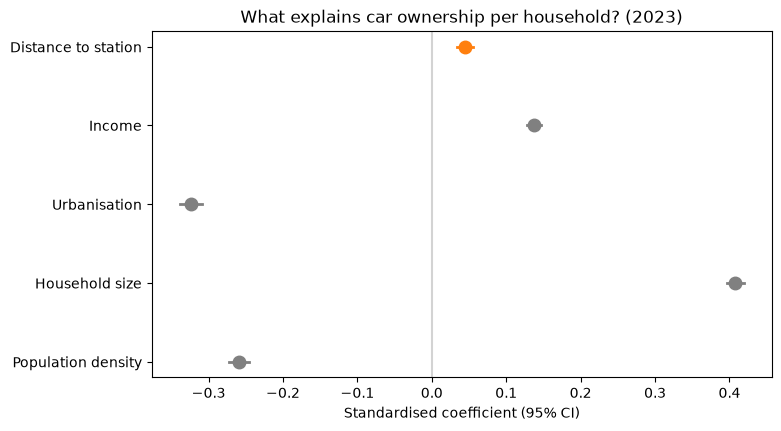

In [ ]:
namen = {'afstand_station': 'Distance to station', 'inkomen': 'Income', 'stedelijk': 'Urbanisation',
         'hh_grootte': 'Household size', 'dichtheid': 'Population density'}

volgorde = ['afstand_station', 'inkomen', 'stedelijk', 'hh_grootte', 'dichtheid']
y_posities = range(len(volgorde), 0, -1)   # top to bottom

fig, ax = plt.subplots(figsize=(8, 4.5))

for y, var in zip(y_posities, volgorde):
    kleur = 'tab:orange' if var == 'afstand_station' else 'grey'   # highlight distance
    ax.plot([ci.loc[var, 0], ci.loc[var, 1]], [y, y], color=kleur, linewidth=2)   # confidence interval
    ax.plot(coef[var], y, 'o', color=kleur, markersize=9)                        # estimate

ax.axvline(0, color='lightgrey', zorder=0)   # line at 0 = no effect
ax.set_yticks(list(y_posities))
ax.set_yticklabels([namen[v] for v in volgorde])
ax.set_xlabel('Standardised coefficient (95% CI)')
ax.set_title('What explains car ownership per household? (2023)')
plt.show()

**Reading the figure:** distance to the station has a positive and significant effect, but it is small compared to household size, urbanisation and density. Neighbourhoods further from a station have somewhat more cars, also after taking the other differences into account.

---
# Part B — SQ3: Is the relation different for major and minor stations?

### Figure B: car ownership vs. distance, per station type

Each dot is a neighbourhood. The line is a simple regression line through the dots (without control variables). We show neighbourhoods up to 20 km from a station (about 96% of all neighbourhoods), so the figure is not stretched by a few very remote areas.

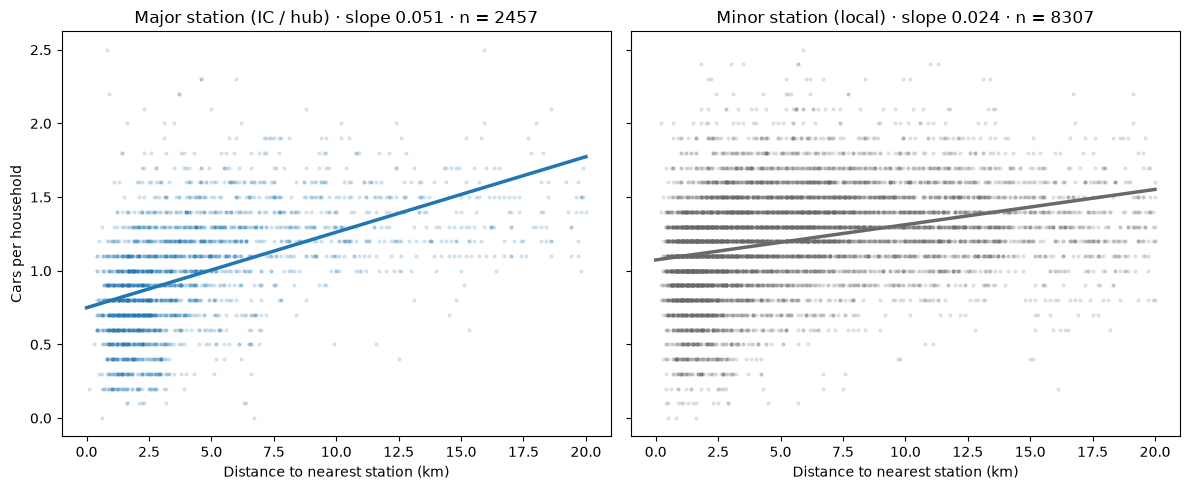

In [ ]:
# Only neighbourhoods up to 20 km, for a readable figure
dichtbij = master[master['afstand_station'] <= 20]

groepen = [(1, 'Major station (IC / hub)', 'tab:blue'),
           (0, 'Minor station (local)', 'dimgrey')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (groot, titel, kleur) in zip(axes, groepen):
    deel = dichtbij[dichtbij['station_groot'] == groot]

    # Simple regression line: slope and intercept with np.polyfit
    helling, snijpunt = np.polyfit(deel['afstand_station'], deel['autos_per_hh'], 1)
    x_lijn = np.array([0, 20])

    ax.scatter(deel['afstand_station'], deel['autos_per_hh'], s=4, alpha=0.15, color=kleur)
    ax.plot(x_lijn, snijpunt + helling * x_lijn, color=kleur, linewidth=2.5)

    ax.set_title(f'{titel} · slope {helling:.3f} · n = {len(deel)}')
    ax.set_xlabel('Distance to nearest station (km)')

axes[0].set_ylabel('Cars per household')
plt.tight_layout()
plt.show()

The slopes above do not take the control variables into account. To test whether the difference is real, we estimate one model with an **interaction** `afstand_station * station_groot` and the control variables.

In [ ]:
model_b = smf.ols('autos_per_hh ~ afstand_station * station_groot + ' + controles, data=master).fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:           autos_per_hh   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     4580.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:36:49   Log-Likelihood:                 3170.2
No. Observations:               11221   AIC:                            -6324.
Df Residuals:                   11213   BIC:                            -6266.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
helling_klein = model_b.params['afstand_station']
helling_groot = helling_klein + model_b.params['afstand_station:station_groot']
p_verschil = model_b.pvalues['afstand_station:station_groot']

print(f'Slope near minor stations (with controls): {helling_klein:.4f} cars per km')
print(f'Slope near major stations (with controls): {helling_groot:.4f} cars per km')
print(f'p-value of the difference: {p_verschil:.3f}')
print(f'Difference in level near a major station: {model_b.params["station_groot"]:.3f} cars per household')

Slope near minor stations (with controls): 0.0022 cars per km
Slope near major stations (with controls): 0.0032 cars per km
p-value of the difference: 0.111
Difference in level near a major station: -0.033 cars per household


**Reading the result:** in the raw data, the line is steeper near major stations. After adding the control variables, both slopes become much smaller and the difference between them is not significant (p > 0.05). Neighbourhoods near a major station do have slightly lower car ownership overall.

---
# Part C — SQ4: Is the relation weaker near stations with many disruptions?

We add an interaction between distance and the number of disruptions. We keep `station_groot` in the model, because major stations also have many more disruptions.

In [ ]:
model_c = smf.ols('autos_per_hh ~ afstand_station * storingen_100 + station_groot + ' + controles, data=master).fit()
print(model_c.summary())

                            OLS Regression Results                            
Dep. Variable:           autos_per_hh   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     4067.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:36:49   Log-Likelihood:                 3231.7
No. Observations:               11221   AIC:                            -6445.
Df Residuals:                   11212   BIC:                            -6380.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
print(f"Interaction distance x disruptions: {model_c.params['afstand_station:storingen_100']:.4f}")
print(f"p-value: {model_c.pvalues['afstand_station:storingen_100']:.3f}")

# Slope of distance at few and at many disruptions
for storingen in [25, 100, 250]:
    helling = model_c.params['afstand_station'] + model_c.params['afstand_station:storingen_100'] * storingen / 100
    print(f'Slope of distance at {storingen} disruptions per year: {helling:.4f} cars per km')

Interaction distance x disruptions: 0.0033
p-value: 0.000
Slope of distance at 25 disruptions per year: 0.0017 cars per km
Slope of distance at 100 disruptions per year: 0.0042 cars per km
Slope of distance at 250 disruptions per year: 0.0091 cars per km


### Figure C: 3D surface (as in the lecture, slide 11)

x = distance, y = disruptions per year, height = predicted car ownership (minor station, control variables at their average).

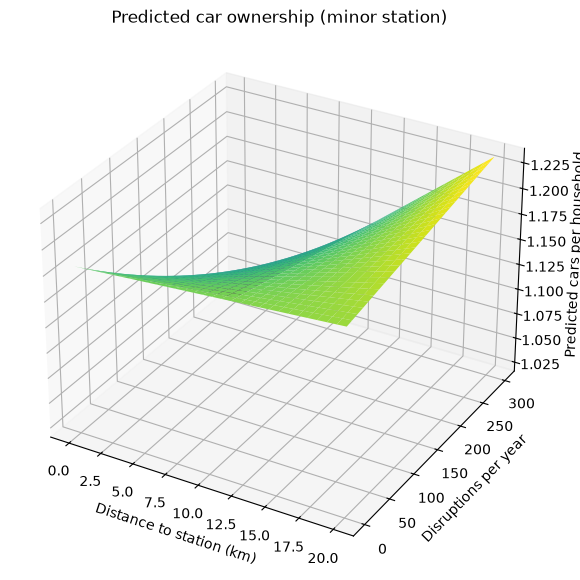

In [ ]:
# Step 1: grid of distances and disruptions (np.meshgrid, as in the lecture)
x = np.linspace(0, 20, 30)     # distance in km
y = np.linspace(0, 3, 30)      # disruptions in hundreds per year
x, y = np.meshgrid(x, y)

# Step 2: a table with every grid point, controls at their average, minor station
gemiddelden = master[['inkomen', 'stedelijk', 'hh_grootte', 'dichtheid_1000']].mean()
raster = pd.DataFrame({'afstand_station': x.flatten(), 'storingen_100': y.flatten(), 'station_groot': 0})
for kolom in gemiddelden.index:
    raster[kolom] = gemiddelden[kolom]

# Step 3: predict and put back in grid shape
z = model_c.predict(raster).to_numpy().reshape(x.shape)

# Step 4: plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y * 100, z, cmap='viridis')

ax.set_xlabel('Distance to station (km)')
ax.set_ylabel('Disruptions per year')
ax.set_zlabel('Predicted cars per household')
ax.set_title('Predicted car ownership (minor station)')
plt.show()

**Reading the result:** the interaction is positive: the effect of distance is *stronger* near stations with many disruptions, not weaker as we expected. A likely explanation is that the stations with the most disruptions are also the busiest stations with the most trains, so the number of disruptions partly measures how much rail service a station offers, not only how unreliable it is.